In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving car_vs_bike.zip to car_vs_bike.zip


In [ ]:
import zipfile

zip_path = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [ ]:
dataset_path = "/content/dataset/Car-Bike-Dataset"

for root,dirs,files in os.walk(dataset_path):
    print(root)

/content/dataset/Car-Bike-Dataset
/content/dataset/Car-Bike-Dataset/Car
/content/dataset/Car-Bike-Dataset/Bike


Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


View Classes

In [ ]:
print(train_generator.class_indices)

{'Bike': 0, 'Car': 1}


Build CNN

In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),

    Dropout(0.5),

   Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Train Model

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15
)

Epoch 1/15
 26/100 ━━━━━━━━━━━━━━━━━━━━ 31s 426ms/step - accuracy: 0.5480 - loss: 1.5426

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


100/100 ━━━━━━━━━━━━━━━━━━━━ 63s 544ms/step - accuracy: 0.7081 - loss: 0.6450 - val_accuracy: 0.8413 - val_loss: 0.3851
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 54s 538ms/step - accuracy: 0.8759 - loss: 0.3131 - val_accuracy: 0.8325 - val_loss: 0.3699
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 531ms/step - accuracy: 0.8816 - loss: 0.2773 - val_accuracy: 0.8725 - val_loss: 0.2764
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 524ms/step - accuracy: 0.9072 - loss: 0.2276 - val_accuracy: 0.8737 - val_loss: 0.2984
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 524ms/step - accuracy: 0.9106 - loss: 0.2117 - val_accuracy: 0.8413 - val_loss: 0.3578
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 533ms/step - accuracy: 0.9072 - loss: 0.2101 - val_accuracy: 0.8963 - val_loss: 0.2783
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 53s 524ms/step - accuracy: 0.9200 - loss: 0.2097 - val_accuracy: 0.8888 - val_loss: 0.2701
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 52s 525ms/step - accuracy: 0.9309 - loss: 0.1706 - val

Accuracy Graph

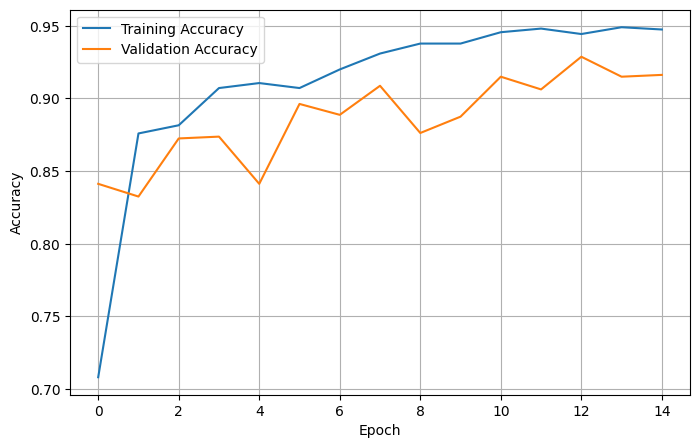

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

Loss Graph

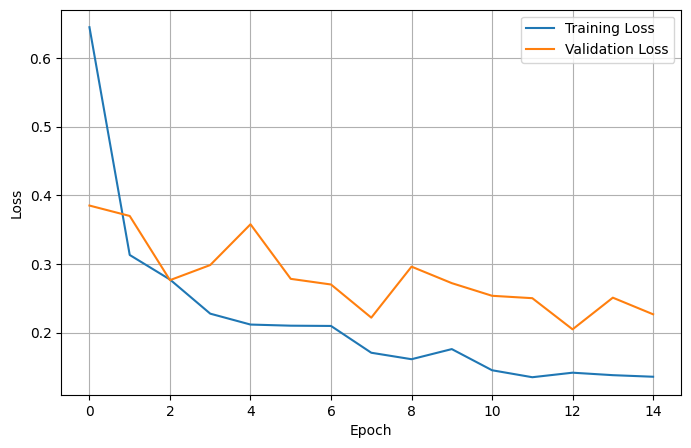

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

Evaluate

In [ ]:
loss,accuracy=model.evaluate(validation_generator)

print("Validation Accuracy :",accuracy*100,"%")

25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 393ms/step - accuracy: 0.9237 - loss: 0.2066
Validation Accuracy : 92.37499833106995 %


Save Model

In [ ]:
model.save("Vehicle_Classification_Model.keras")

Upload Custom Images

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bike.jpg to bike.jpg
Saving car.jpg to car.jpg


Prediction Function

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_vehicle(img_path):

    # Load image
    img = image.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # Preprocess image
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = img / 255.0

    # Predict
    prediction = model.predict(img, verbose=0)[0][0]

    # Binary Classification
    if prediction >= 0.5:
        predicted_class = "Car"
        confidence = prediction * 100
    else:
        predicted_class = "Bike"
        confidence = (1 - prediction) * 100

    print("Prediction :", predicted_class)
    print("Confidence : {:.2f}%".format(confidence))

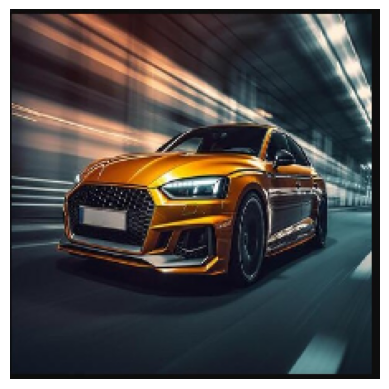

Prediction : Car
Confidence : 100.00%


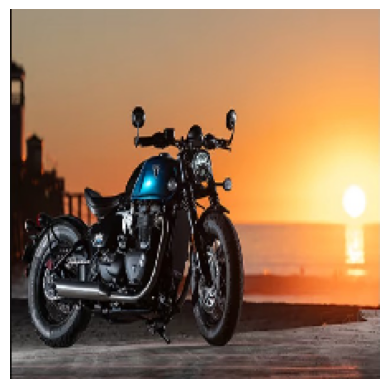

Prediction : Bike
Confidence : 95.53%


In [ ]:
predict_vehicle("car.jpg")
predict_vehicle("bike.jpg")